# 21 — Unique source counts from the production detector (Q1, 790 ECDFS tiles)

**Question:** how many unique sources does the production CenterNet+SEP detector find
across the 790 ECDFS Q1 tiles, after removing cross-tile duplicates?

The tiles are 1084 px (~108") VIS crops on a 256-px stride grid, so they overlap heavily
and the same physical source is detected in up to ~4 tiles. We convert every detection to
RA/Dec via each tile's VIS WCS and apply the same greedy score-ordered clustering used by
`models/astrometry2/dedup_anchors.py`, sweeping the dedup radius to find the plateau.

Inputs:
- `data/detection_labels/centernet_q1_790_vissep_thresh03.pt` — production catalog
  (CenterNet vis+SEP head, conf ≥ 0.3, `checkpoints/q1_detection/centernet_vis_sep.pt`)
- `data/euclid_tiles_all_q1/*.npz` — tile WCS

In [1]:
import warnings
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
LABELS_PT = ROOT / "data/detection_labels/centernet_q1_790_vissep_thresh03.pt"
TILE_DIR = ROOT / "data/euclid_tiles_all_q1"

d = torch.load(LABELS_PT, map_location="cpu", weights_only=False)
labels, scores, config = d["labels"], d["scores"], d["config"]

n_raw = sum(len(v[0]) for v in labels.values())
print(f"tiles: {len(labels)}   raw detections: {n_raw}   ({n_raw/len(labels):.0f}/tile)")
print(f"detector: {config['centernet_ckpt']}   conf_threshold: {config['conf_threshold']}")

tiles: 790   raw detections: 176867   (224/tile)
detector: checkpoints/q1_detection/centernet_vis_sep.pt   conf_threshold: 0.3


## Detections → sky coordinates

Detection centroids are stored as normalized `(x, y)` in `[0, 1]`
(`positions_px = norm * (W-1, H-1)`, see `centernet_detector.py`); we push them through
each tile's `wcs_VIS`.

In [2]:
ras, decs, scs, tile_idx = [], [], [], []
for ti, (key, (coords, _)) in enumerate(labels.items()):
    if len(coords) == 0:
        continue
    z = np.load(TILE_DIR / f"{key}_euclid.npz", allow_pickle=True)
    w = WCS(fits.Header.fromstring(str(z["wcs_VIS"])))
    n = z["img_VIS"].shape[0]
    xy = np.asarray(coords, dtype=np.float64) * (n - 1)
    ra_t, dec_t = w.wcs_pix2world(xy[:, 0], xy[:, 1], 0)
    ras.append(ra_t); decs.append(dec_t)
    scs.append(np.asarray(scores[key], dtype=np.float64))
    tile_idx.append(np.full(len(ra_t), ti))

ra = np.concatenate(ras); dec = np.concatenate(decs)
sc = np.concatenate(scs); tile_idx = np.concatenate(tile_idx)
print(f"{ra.size} detections with sky coordinates")

# local tangent-plane projection (arcsec) for the KD-tree
ra0, dec0 = np.median(ra), np.median(dec)
cosd = np.cos(np.deg2rad(dec0))
pts = np.stack([(ra - ra0) * cosd * 3600.0, (dec - dec0) * 3600.0], axis=1)
tree = cKDTree(pts)

176867 detections with sky coordinates


## Greedy dedup, sweeping the radius

Same operation as `dedup_anchors.py`: visit detections in descending score; each kept
detection kills every neighbour within the radius. The anchor catalogs use 50 mas
(head-refined positions land at ~0 mas), but these are raw CenterNet positions, so
cross-tile duplicates scatter by up to ~1 VIS pixel (100 mas) — we sweep to locate the
plateau instead of assuming a radius.

In [3]:
def dedup_count(radius_arcsec):
    keep = np.ones(ra.size, dtype=bool)
    for idx in np.argsort(sc)[::-1]:
        if not keep[idx]:
            continue
        for j in tree.query_ball_point(pts[idx], r=radius_arcsec):
            if j != idx:
                keep[j] = False
    return keep

radii = np.array([0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50])
keeps = {r: dedup_count(r) for r in radii}

header = 'radius ["]'
print(f"{header:>12} {'unique':>9} {'kept':>7}")
for r in radii:
    n = keeps[r].sum()
    print(f"{r:>12.2f} {n:>9d} {n/ra.size*100:>6.1f}%")

  radius ["]    unique    kept
        0.02    120561   68.2%
        0.05     64739   36.6%
        0.10     50122   28.3%
        0.15     48384   27.4%
        0.20     47940   27.1%
        0.30     47547   26.9%
        0.50     47189   26.7%


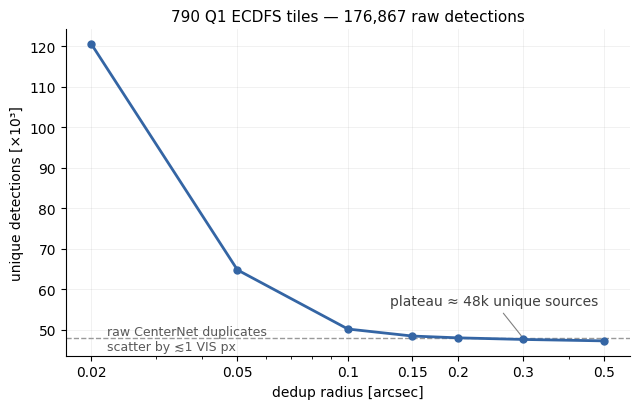

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
counts = np.array([keeps[r].sum() for r in radii])
ax.plot(radii, counts / 1e3, marker="o", ms=5, lw=2, color="#3465a4")
ax.axhline(counts[radii == 0.20][0] / 1e3, color="0.6", lw=1, ls="--", zorder=0)
ax.annotate(f"plateau ≈ {counts[radii == 0.20][0]/1e3:.0f}k unique sources",
            xy=(0.30, counts[radii == 0.20][0] / 1e3), xytext=(0.13, 56),
            fontsize=10, color="0.25",
            arrowprops=dict(arrowstyle="-", color="0.5", lw=0.8))
ax.annotate("raw CenterNet duplicates\nscatter by ≲1 VIS px",
            xy=(0.05, keeps[0.05].sum() / 1e3), xytext=(0.022, 45),
            fontsize=9, color="0.35")
ax.set_xscale("log")
ax.set_xticks(radii)
ax.set_xticklabels([f"{r:g}" for r in radii])
ax.set_xlabel("dedup radius [arcsec]")
ax.set_ylabel("unique detections [×10³]")
ax.set_title(f"790 Q1 ECDFS tiles — {ra.size:,} raw detections", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()
plt.show()

## Sky density of the deduplicated catalog

Unique sources at the 0.2" plateau radius, as a density map over the six tract-5063
patches. Uniform coverage (no tile-boundary imprint) is the visual check that the dedup
removed the overlap duplicates rather than real neighbours.

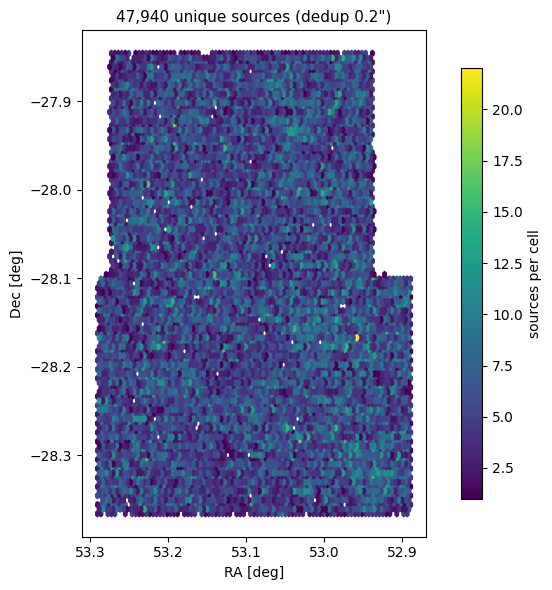

~231k sources / deg^2 over ~0.21 deg^2


In [5]:
keep = keeps[0.20]

fig, ax = plt.subplots(figsize=(7.2, 6))
hb = ax.hexbin(ra[keep], dec[keep], gridsize=90, cmap="viridis", mincnt=1)
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.invert_xaxis()
ax.set_aspect(1.0 / cosd)
ax.set_title(f"{keep.sum():,} unique sources (dedup 0.2\")", fontsize=11)
cb = fig.colorbar(hb, ax=ax, shrink=0.85)
cb.set_label("sources per cell")
plt.tight_layout()
plt.show()

# implied surface density
area_deg2 = 6 * (670.0 / 3600.0) ** 2  # six patches, ~670\" square footprint each
print(f"~{keep.sum()/area_deg2/1e3:.0f}k sources / deg^2 over ~{area_deg2:.2f} deg^2")

## Conclusion

The production detector yields **176,867 raw detections** across the 790 ECDFS Q1 tiles
(~224 per tile). After sky-coordinate dedup the count plateaus between 0.1" and 0.2" —
the signature of cross-tile duplicates landing within ~1 VIS pixel — at
**≈48–50k unique sources** (~3.7× average duplication, consistent with the ~4× geometric
tile overlap). The implied surface density, ~230k sources/deg², is in the expected range
for VIS ≈ 25 depth. The catalog includes stars; at ECDFS's galactic latitude and this
depth the star fraction is small (order 5–10%), so approximately **~45–47k of the unique
sources are galaxies**.

Note the 50 mas radius used for the head-refined anchor catalogs *undercounts* duplicates
on raw CenterNet positions (65k survivors at 0.05"); the plateau value is the physically
meaningful count.